# Part 4a / 4b — From cooperative planner to a two-firm game

### Where one objective function stops being enough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USERNAME/lithium-modelling/blob/main/notebooks/04ab_planner_and_game.ipynb)

Parts 1–3b all had **one** objective, which means one decision maker. This
notebook takes the first two steps toward rivalry:

| | Model | Method | What it is |
|---|---|---|---|
| **4a** | one planner, two weighted regional costs | MILP, sweep the weight | **Not a game.** A cooperative bound and a Pareto frontier |
| **4b** | two firms, **fixed** price | iterative best response | The first genuine strategic interaction |

Part 4c (endogenous price), 4d (Stackelberg via KKT) and 4e (policy instruments)
follow.

### Institutional split: government constrains, firms optimise

- **Government** sets non-market constraints — local content minimums, tariffs,
  quotas. Exogenous and swept, never chosen by the model. Part 4e is where they
  arrive.
- **Firms** are profit maximisers operating inside those constraints. One firm
  per region.

That split is what justifies per-tier demand minimums as *policy* rather than as
a modelling trick, and it avoids a trilevel structure where governments and firms
both optimise.

### Structural change from Part 3b: vertical integration

In Part 3b any stage could source from either region. That is fine for a single
planner, but in a game it would need an internal transfer price between rival
firms at every stage — a modelling problem in its own right. So from here on:

- each firm owns a **vertically integrated chain** inside its own region
  (MINE → PROC → MFG)
- firms **compete downstream**, delivering finished product into either region's
  demand market
- cross-region delivery pays a transport premium, 2.4 against 0.5

### An asymmetric instance, deliberately

Symmetric regions produce symmetric results and teach nothing about entry. R1
begins deep into its learning curve; R2 is cheaper to build but starts
inexperienced. The question is whether R2 can buy its way down the curve before
R1's cost advantage locks it out. Section 2 loads the numbers and section 2.1
prints them keyed the way the model indexes.

### How to read this notebook

Sections 5 and 6 build the chain and the planner **by hand** — that is Part 4a,
and it is the model every later Part 4 notebook reuses. Section 9 builds Part
4b's best response by hand: one new constraint, and it carries the entire
strategic content. Section 10 wraps what you built, and section 14 asserts the
notebook and the `lithium` package agree to $10^{-9}$.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/USERNAME/lithium-modelling.git"   # <-- edit me
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 2. The instance tables

Two kinds of number go into this model and they are treated differently.

A **knob** is a scalar carrying a concept — the discount rate, the number of revenue breakpoints,
the choke price. Knobs stay written out in the cell where they are explained, because seeing
`NBP_REV = 7` next to the sentence describing what a breakpoint mesh does *is* the lesson. This
notebook hands every knob to the package explicitly in section 14, so the agreement assertion covers
them.

A **table** is instance data — many entries, indexed by the model's own sets, named nowhere in the
prose. Tables live in `data/raw/`, and both this notebook and `src/lithium/` read the same file. If
each typed its own copy, a failed assertion could not tell a typo in the data from a bug in a
constraint. Three tables, three key structures:

| file | keyed by | rows |
|---|---|---|
| `instance_base.csv` | `(stage, region)` | 6 |
| `efficiency.csv` | `stage` | 3 |
| `market.csv` | `region` | 2 |

Read the base table first and look at it as a **frame** — rows and columns — before turning it into
anything the model can index.

In [2]:
DATA = Path("data/raw")

if not (DATA / "instance_base.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run and every figure will render, but the")
    print("! results are NOT the shipped instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run this notebook from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "instance_base.csv").write_text(
        "stage,region,fixed,unit,opex,legacy_cap,legacy_ret\n"
        + "\n".join(f"{s},{r},1000.0,8.0,2.0,150,15"
                    for r in ("R1", "R2") for s in ("MINE", "PROC", "MFG")) + "\n")
    (DATA / "efficiency.csv").write_text(
        "stage,eta_ceil,eta_base,alpha,beta,delta_bar\n"
        "MINE,0.92,0.86,0.0,0.0,0.02\nPROC,0.95,0.80,0.03,0.01,0.05\n"
        "MFG,0.93,0.78,0.025,0.008,0.05\n")
    (DATA / "market.csv").write_text(
        "region,demand_base,demand_growth,experience0\n"
        "R1,100.0,0.008,1000.0\nR2,75.0,0.026,1000.0\n")

base = pd.read_csv(DATA / "instance_base.csv")
print(f"instance_base.csv: {len(base)} rows x {len(base.columns)} columns")
base

instance_base.csv: 6 rows x 7 columns


,stage,region,fixed,unit,opex,legacy_cap,legacy_ret
0,MINE,R1,900.0,7.0,1.20,230,11
1,PROC,R1,1500.0,11.0,2.00,205,14
2,MFG,R1,1300.0,9.5,2.40,155,18
3,MINE,R2,820.0,6.4,1.35,165,9
4,PROC,R2,1350.0,10.0,2.20,125,16
5,MFG,R2,1180.0,8.7,2.60,100,22


The other two tables. `efficiency.csv` is keyed by stage alone — a mine's yield behaviour does not
depend on which region owns it — and `market.csv` is keyed by region alone.

In [3]:
eff = pd.read_csv(DATA / "efficiency.csv")
mkt = pd.read_csv(DATA / "market.csv")
print(f"efficiency.csv: {len(eff)} rows    market.csv: {len(mkt)} rows")
display(eff)
mkt

efficiency.csv: 3 rows    market.csv: 2 rows


,stage,eta_ceil,eta_base,alpha,beta,delta_bar
0,MINE,0.92,0.86,0.000,0.000,0.02
1,PROC,0.95,0.80,0.030,0.010,0.05
2,MFG,0.93,0.78,0.025,0.008,0.05


,region,demand_base,demand_growth,experience0
0,R1,100.0,0.008,2600.0
1,R2,75.0,0.026,500.0


### 2.1 From table to lookup — see the key

A frame shows rows and columns. **The model does not index by row number.** Every constraint below
looks a value up by a *key*: `FIXED['PROC', 'R1']`, `ETA_CEIL['MFG']`, `EXPERIENCE0['R2']`. That key
is what connects the data to the algebra, so build the dictionaries and print them in the form the
constraints will actually use, rather than leaving the index set implied by punctuation.

The two index sets come out of the tables themselves, in file order — so the order the model
iterates in is a property of the data, not of a sorted() call somewhere.

In [4]:
STAGES = list(dict.fromkeys(eff["stage"]))
REGIONS = list(dict.fromkeys(mkt["region"]))

FIXED = {(r.stage, r.region): r.fixed for r in base.itertuples()}
UNIT = {(r.stage, r.region): r.unit for r in base.itertuples()}
OPEX = {(r.stage, r.region): r.opex for r in base.itertuples()}
LEGACY_CAP = {(r.stage, r.region): float(r.legacy_cap) for r in base.itertuples()}
LEGACY_RET = {(r.stage, r.region): int(r.legacy_ret) for r in base.itertuples()}

print(f"index sets:  STAGES  = {STAGES}")
print(f"             REGIONS = {REGIONS}")
print(f"{len(FIXED)} keys, each a (stage, region) tuple\n")
print(f"{'key':18s} {'FIXED':>8s} {'UNIT':>7s} {'OPEX':>6s} {'LEG_CAP':>8s} {'LEG_RET':>8s}")
for s in STAGES:
    for r in REGIONS:
        print(f"{str((s, r)):18s} {FIXED[s, r]:8.1f} {UNIT[s, r]:7.2f} {OPEX[s, r]:6.2f}"
              f" {LEGACY_CAP[s, r]:8.0f} {LEGACY_RET[s, r]:8d}")

index sets:  STAGES  = ['MINE', 'PROC', 'MFG']
             REGIONS = ['R1', 'R2']
6 keys, each a (stage, region) tuple

key                   FIXED    UNIT   OPEX  LEG_CAP  LEG_RET
('MINE', 'R1')        900.0    7.00   1.20      230       11
('MINE', 'R2')        820.0    6.40   1.35      165        9
('PROC', 'R1')       1500.0   11.00   2.00      205       14
('PROC', 'R2')       1350.0   10.00   2.20      125       16
('MFG', 'R1')        1300.0    9.50   2.40      155       18
('MFG', 'R2')        1180.0    8.70   2.60      100       22


The same move for the two single-key tables. Note `EXPERIENCE0`: R1 starts with 2,600 units of
accumulated production experience against R2's 500. Nothing in this instance is labelled
"incumbent" — that word is a *reading* of three numbers pulling the same way: R1 starts with more
experience, larger inherited plants, and the bigger home market. R2's compensating advantage is in
`instance_base.csv`, and it is capital, not operating cost: R2 is cheaper to **build** at every stage
and more expensive to **run** at every stage. Check that against the table above before going on,
because most of the results below turn on it.

In [5]:
ETA_CEIL = {r.stage: r.eta_ceil for r in eff.itertuples()}
ETA_BASE = {r.stage: r.eta_base for r in eff.itertuples()}
ALPHA = {r.stage: r.alpha for r in eff.itertuples()}
BETA = {r.stage: r.beta for r in eff.itertuples()}
DELTA_BAR = {r.stage: r.delta_bar for r in eff.itertuples()}

DEMAND_BASE = {r.region: r.demand_base for r in mkt.itertuples()}
DEMAND_GROWTH = {r.region: r.demand_growth for r in mkt.itertuples()}
EXPERIENCE0 = {r.region: r.experience0 for r in mkt.itertuples()}

print("keyed by stage :")
for s in STAGES:
    print(f"  {s!r:8s} ceil {ETA_CEIL[s]:.2f}  base {ETA_BASE[s]:.2f}  alpha {ALPHA[s]:.3f}"
          f"  beta {BETA[s]:.3f}  delta_bar {DELTA_BAR[s]:.2f}")
print("\nkeyed by region:")
for r in REGIONS:
    print(f"  {r!r:6s} demand_base {DEMAND_BASE[r]:6.1f}  growth {DEMAND_GROWTH[r]:.3f}"
          f"  experience0 {EXPERIENCE0[r]:7.1f}")

keyed by stage :
  'MINE'   ceil 0.92  base 0.86  alpha 0.000  beta 0.000  delta_bar 0.02
  'PROC'   ceil 0.95  base 0.80  alpha 0.030  beta 0.010  delta_bar 0.05
  'MFG'    ceil 0.93  base 0.78  alpha 0.025  beta 0.008  delta_bar 0.05

keyed by region:
  'R1'   demand_base  100.0  growth 0.008  experience0  2600.0
  'R2'   demand_base   75.0  growth 0.026  experience0   500.0


### 2.2 Want to experiment? Change a number here, not in the CSV

Each table is now a dictionary keyed the way the model indexes. Assign to a key to override one
entry. The change flows into every model built below **and** into the section 14 agreement check,
because the package takes the data as an argument instead of re-reading the file — so the assertion
stays green and you can see exactly what your edit did.

In [6]:
# ---------------------------------------------------------------------------
# Example - give R2 the same processing opex as R1 (2.0 instead of its 2.2):
#
#     OPEX['PROC', 'R2'] = 2.00
#
# Uncomment, then re-run this cell and everything below it. This erases R1's
# operating-cost edge at the processing stage, so R2 gets cheaper to run, its
# equilibrium share rises, and the section 14 assertion stays green because the
# notebook passes OPEX to the package rather than letting it re-read the file.
# Re-run with it commented out to get the shipped instance back.
# ---------------------------------------------------------------------------
print(f"OPEX['PROC', 'R2'] is currently {OPEX['PROC', 'R2']}")

OPEX['PROC', 'R2'] is currently 2.2


## 3. The knobs, and the structure derived from them

Everything from here to section 5 is **derived**: sets, windows, discount weights, yields. None of
it is data and none of it is a knob — it is arithmetic on the two, and doing that arithmetic is the
point of this section. `src/lithium/structure.py` computes exactly the same things, and section 14
is what proves the two derivations agree.

### 3.1 Time: variable-length periods

A 37-year horizon at annual resolution would be 37 copies of every decision. Instead the horizon is
chopped into **13 periods of increasing length** — six 1-year periods while the interesting things
happen, then 3-, 5- and finally 9-year blocks. `OMEGA[p]` is the sum of discount factors for the
years inside period `p`, so a long late period is correctly worth less per year *and* covers more
years.

In [7]:
BLOCKS = [(6, 1), (4, 3), (2, 5), (1, 9)]   # (how many periods, how many years each)
DR = 0.05                                    # discount rate

LEN, START = [], []
_y = 1
for _count, _length in BLOCKS:
    for _ in range(_count):
        LEN.append(_length)
        START.append(_y)
        _y += _length

P = list(range(len(LEN)))
HORIZON = _y - 1
YEARS = {p: list(range(START[p], START[p] + LEN[p])) for p in P}
OMEGA = {p: sum(1 / (1 + DR) ** t for t in YEARS[p]) for p in P}
YEAR_TO_P = {t: p for p in P for t in YEARS[p]}

print(f"{len(P)} periods covering {HORIZON} years")
print(f"{'p':>3s} {'start':>6s} {'len':>4s} {'OMEGA':>8s}")
for p in P:
    print(f"{p:3d} {START[p]:6d} {LEN[p]:4d} {OMEGA[p]:8.4f}")

13 periods covering 37 years
  p  start  len    OMEGA
  0      1    1   0.9524
  1      2    1   0.9070
  2      3    1   0.8638
  3      4    1   0.8227
  4      5    1   0.7835
  5      6    1   0.7462
  6      7    3   2.0321
  7     10    3   1.7554
  8     13    3   1.5164
  9     16    3   1.3099
 10     19    5   1.7990
 11     24    5   1.4096
 12     29    9   1.8132


### 3.2 Technology: turning a lump of capex into an annual charge

A plant built in period `v` is paid for once and used for `LIFE` years. `CRF` is the capital
recovery factor that spreads that lump into equal annual payments, and `MU[s, v]` discounts those
payments back to today — truncated at the horizon, so a plant built late gets credit only for the
years that actually fall inside the model.

`LEAD` is the construction lag: decide in period `v`, produce from `START[v] + LEAD[s]`.

In [8]:
LIFE = 25
LEAD = {'MINE': 1, 'PROC': 2, 'MFG': 2}
CAP_MIN, CAP_MAX = 60.0, 260.0

CRF = DR * (1 + DR) ** LIFE / ((1 + DR) ** LIFE - 1)
ONLINE = {(s, p): START[p] + LEAD[s] for s in STAGES for p in P}
MU = {(s, v): CRF * sum(1 / (1 + DR) ** t
                        for t in range(ONLINE[s, v], ONLINE[s, v] + LIFE)
                        if t <= HORIZON)
      for s in STAGES for v in P}

print(f"CRF = {CRF:.6f}   (a 1.0 lump becomes {CRF:.4f} per year for {LIFE} years)")
print(f"\nMU['PROC', v] by build period - note the collapse as v approaches the horizon:")
print("  " + "  ".join(f"v{v}:{MU['PROC', v]:5.2f}" for v in P))

CRF = 0.070952   (a 1.0 lump becomes 0.0710 per year for 25 years)

MU['PROC', v] by build period - note the collapse as v approaches the horizon:
  v0: 0.91  v1: 0.86  v2: 0.82  v3: 0.78  v4: 0.75  v5: 0.71  v6: 0.68  v7: 0.58  v8: 0.48  v9: 0.39  v10: 0.30  v11: 0.19  v12: 0.09


### 3.3 Efficiency: yield depends on when a plant was built and how old it is

Two effects, and they pull in opposite directions. A plant built later starts closer to the
technological ceiling (`ALPHA` — the frontier improves). A plant that has been running for a while
also drifts up towards the ceiling through operating experience (`BETA`), but only by at most
`DELTA_BAR` above where it started. `ETA_FLOOR` stops the arithmetic producing a nonsense yield.

`LEGACY_BYR = -8` says the inherited plants were built eight years before year 1 — which is why they
sit well below the frontier.

In [9]:
ETA_FLOOR = 0.60
LEGACY_BYR = -8

VINTAGES = [-1] + P                      # -1 is the inherited fleet
BYEAR = {v: (LEGACY_BYR if v == -1 else START[v]) for v in VINTAGES}

ETA = {}
for s in STAGES:
    for v in VINTAGES:
        fr = ETA_CEIL[s] - (ETA_CEIL[s] - ETA_BASE[s]) * (1 - ALPHA[s]) ** (BYEAR[v] - 1)
        fr = max(ETA_FLOOR, min(fr, ETA_CEIL[s]))
        for p in P:
            age = max(0, START[p] - BYEAR[v])
            aged = ETA_CEIL[s] - (ETA_CEIL[s] - fr) * (1 - BETA[s]) ** age
            ETA[s, v, p] = max(ETA_FLOOR, min(fr + DELTA_BAR[s], aged))

print(f"{len(ETA)} yields, keyed (stage, vintage, period)\n")
print("PROC yield in period 0, by vintage - the frontier effect:")
print("  legacy (v=-1): %.4f" % ETA['PROC', -1, 0])
print("  " + "  ".join(f"v{v}:{ETA['PROC', v, 0]:.4f}" for v in P[:5]))
print("\nlegacy PROC plant ageing through the horizon:")
print("  " + "  ".join(f"p{p}:{ETA['PROC', -1, p]:.4f}" for p in P[:6]))

546 yields, keyed (stage, vintage, period)

PROC yield in period 0, by vintage - the frontier effect:
  legacy (v=-1): 0.7698
  v0:0.8000  v1:0.8045  v2:0.8089  v3:0.8131  v4:0.8172

legacy PROC plant ageing through the horizon:
  p0:0.7698  p1:0.7716  p2:0.7733  p3:0.7751  p4:0.7769  p5:0.7786


### 3.4 Demand

Each region's demand grows from its own base at its own rate. R2 is the smaller market but grows
more than three times as fast, which is why the entrant's home turf is worth fighting for later even
though it is worth less now. The value stored is the **average annual** demand across the period, so
it is comparable across periods of different length.

In [10]:
DEMAND = {(r, p): sum(DEMAND_BASE[r] * (1 + DEMAND_GROWTH[r]) ** (t - 1) for t in YEARS[p]) / LEN[p]
          for r in REGIONS for p in P}

print(f"average annual demand ({len(DEMAND)} keys, (region, period)):")
print(f"{'p':>3s} {'year':>5s} " + " ".join(f"{r:>8s}" for r in REGIONS))
for p in P:
    print(f"{p:3d} {START[p]:5d} " + " ".join(f"{DEMAND[r, p]:8.2f}" for r in REGIONS))

average annual demand (26 keys, (region, period)):
  p  year       R1       R2
  0     1   100.00    75.00
  1     2   100.80    76.95
  2     3   101.61    78.95
  3     4   102.42    81.00
  4     5   103.24    83.11
  5     6   104.06    85.27
  6     7   105.74    89.78
  7    10   108.30    96.97
  8    13   110.92   104.73
  9    16   113.60   113.11
 10    19   117.28   125.40
 11    24   122.05   142.57
 12    29   129.07   170.90


### 3.5 Who can produce, when

Three sets that every constraint below indexes over, and they are worth printing rather than
trusting:

- `ACTIVE[r]` — the `(stage, vintage, period)` triples that exist at all: an inherited plant until
  its retirement year, a new plant from the period it comes online until it has run for `LIFE` years.
- `VIN[r, s, p]` — the vintages available at one stage in one period. This is the set the chain
  balance sums over.
- `BUILD[r]` — the `(stage, vintage)` pairs that could be built, i.e. those that come online before
  the horizon ends.

In [11]:
ACTIVE = {r: [(s, v, p) for s in STAGES for v in VINTAGES for p in P
              if (v == -1 and START[p] <= LEGACY_RET[s, r])
              or (v >= 0 and ONLINE[s, v] <= START[p] <= ONLINE[s, v] + LIFE - 1)]
          for r in REGIONS}
VIN = {(r, s, p): [v for (ss, v, pp) in ACTIVE[r] if (ss, pp) == (s, p)]
       for r in REGIONS for s in STAGES for p in P}
BUILD = {r: [(s, v) for s in STAGES for v in P if ONLINE[s, v] <= HORIZON]
         for r in REGIONS}

for r in REGIONS:
    print(f"{r}: {len(ACTIVE[r]):4d} active (stage, vintage, period) triples, "
          f"{len(BUILD[r]):3d} buildable (stage, vintage) pairs")
print(f"\nVIN['R1', 'MFG', p] - vintages that can manufacture, period by period:")
for p in P:
    print(f"  p{p:<2d} {VIN['R1', 'MFG', p]}")

R1:  242 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs
R2:  243 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs

VIN['R1', 'MFG', p] - vintages that can manufacture, period by period:
  p0  [-1]
  p1  [-1]
  p2  [-1, 0]
  p3  [-1, 0, 1]
  p4  [-1, 0, 1, 2]
  p5  [-1, 0, 1, 2, 3]
  p6  [-1, 0, 1, 2, 3, 4]
  p7  [-1, 0, 1, 2, 3, 4, 5, 6]
  p8  [-1, 0, 1, 2, 3, 4, 5, 6, 7]
  p9  [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  p10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  p11 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  p12 [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


### 3.6 The remaining knobs: moving goods and the two penalties

`TRANSPORT` is nearly five times more expensive across regions than within one. That single number
is what makes geography matter — without it the two markets would collapse into one.

In [12]:
TRANSPORT_OWN, TRANSPORT_CROSS = 0.5, 2.4
TRANSPORT = {(rf, rt): (TRANSPORT_OWN if rf == rt else TRANSPORT_CROSS)
             for rf in REGIONS for rt in REGIONS}

PRICE_FIXED = 12.0     # the Part 4b price; kept so 4b's revenue term stays available
PEN_SHORT = 90.0       # planner-only: cost of leaving demand unserved
PEN_DISPOSE = 12.0     # cost of destroying output rather than selling it

print("TRANSPORT, keyed (from, to):")
for k, v in TRANSPORT.items():
    print(f"  {str(k):14s} {v:4.1f}")
print(f"\nPEN_DISPOSE = {PEN_DISPOSE}  <- watch this one: section 10 shows it never binds")

TRANSPORT, keyed (from, to):
  ('R1', 'R1')    0.5
  ('R1', 'R2')    2.4
  ('R2', 'R1')    2.4
  ('R2', 'R2')    0.5

PEN_DISPOSE = 12.0  <- watch this one: section 10 shows it never binds


## 4. The capacity-learning curve

Building capacity gets cheaper the more of it you have built. A learning rate `LR_CAPEX = 0.15`
means unit cost falls 15% per doubling of cumulative capacity, which is the exponent
$-\log_2(1 - 0.15)$.

**The model needs the area under that curve, not the curve itself.** Total spend to go from
`Q_START` to `Q` is the integral of the unit cost over that range — building the 401st unit costs
what the curve says at 401, not what it said at 300. So we integrate numerically (trapezoid rule,
`PANELS` panels) at each of `NBP` breakpoints, and the model interpolates between them.

**This curve is concave and it enters a cost we are *minimising*** — so a chord between two
breakpoints lies *below* the true cumulative cost, and a free convex combination would happily mix
distant breakpoints to claim a discount that does not exist. That is why the model in section 5 adds
**SOS2** here. Compare section 7.5 of Part 4c, where the same concave shape in a *maximisation* needs nothing.

In [13]:
import math

LEARN_STAGES = ['PROC', 'MFG']
LR_CAPEX = 0.15        # cost falls 15% per doubling
Q_START = 300.0        # cumulative capacity at which learning starts
Q_ADD = 700.0          # how much further the mesh reaches
CAPEX_FLOOR = 0.60     # the multiplier cannot fall below this
NBP = 9                # breakpoints on the capex mesh
PANELS = 400           # trapezoid panels per breakpoint

_bc = -math.log2(1 - LR_CAPEX)
K = list(range(NBP))                     # the breakpoint index the model sums over
QBP = [Q_START + Q_ADD * k / (NBP - 1) for k in K]

CBP = []
for q in QBP:
    if q <= Q_START:
        CBP.append(0.0)
        continue
    h = (q - Q_START) / PANELS
    grid = [Q_START + i * h for i in range(PANELS + 1)]
    unit = [max(CAPEX_FLOOR, (g / Q_START) ** (-_bc)) for g in grid]
    CBP.append(sum(0.5 * (unit[i] + unit[i + 1]) * h for i in range(PANELS)))

print(f"learning exponent b = {_bc:.4f}\n")
print(f"{'k':>2s} {'QBP (cum capacity)':>19s} {'unit mult':>10s} {'CBP (cum spend mult)':>21s}")
for k in range(NBP):
    print(f"{k:2d} {QBP[k]:19.1f} {max(CAPEX_FLOOR, (QBP[k] / Q_START) ** (-_bc)):10.4f}"
          f" {CBP[k]:21.2f}")

learning exponent b = 0.2345

 k  QBP (cum capacity)  unit mult  CBP (cum spend mult)
 0               300.0     1.0000                  0.00
 1               387.5     0.9418                 84.82
 2               475.0     0.8979                165.22
 3               562.5     0.8630                242.20
 4               650.0     0.8342                316.42
 5               737.5     0.8099                388.32
 6               825.0     0.7888                458.24
 7               912.5     0.7704                526.44
 8              1000.0     0.7541                593.12


## 5. The chain, built by hand

A **region** here is a whole vertically-integrated business: it mines ore, processes it, manufactures
the finished good, and sells into either market. The next seven cells build that chain for both
regions, one block of constraints at a time.

We build it first as a **cooperative planner** — one decision maker minimising the weighted sum of
both regions' costs subject to meeting demand. That is Part 4a's model, and we need it here for a
specific reason given in section 6: it tells us the *scale* at which this chain operates, and the
operating-cost learning tiers have to be calibrated against a scale.

### 5.1 The decision variables

Seven families per region. `b` is the only binary block — build or don't — and everything else is
continuous, which is a deliberate choice from Part 3 that pays off in Part 4d.

In [14]:
m = gp.Model("planner")
m.Params.OutputFlag = 0
m.Params.MIPGap = 0.005

b, c, x, f_mp, f_pf, sale, disp = {}, {}, {}, {}, {}, {}, {}
for r in REGIONS:
    b[r] = m.addVars(BUILD[r], vtype=GRB.BINARY, name=f'b_{r}')      # build it?
    c[r] = m.addVars(BUILD[r], lb=0.0, ub=CAP_MAX, name=f'c_{r}')    # how big?
    x[r] = m.addVars(ACTIVE[r], lb=0.0, name=f'x_{r}')               # throughput
    f_mp[r] = m.addVars(P, lb=0.0, name=f'fmp_{r}')                  # mine -> proc flow
    f_pf[r] = m.addVars(P, lb=0.0, name=f'fpf_{r}')                  # proc -> mfg flow
    sale[r] = m.addVars(REGIONS, P, lb=0.0, name=f'sale_{r}')        # sales into each market
    disp[r] = m.addVars(P, lb=0.0, name=f'disp_{r}')                 # destroyed output

m.update()
print(f"{m.NumVars} variables, of which {m.NumBinVars} binary")
print(f"per region: {len(BUILD['R1'])} build pairs, {len(ACTIVE['R1'])} throughput triples")

Set parameter Username


Set parameter LicenseID to value 2750151


Academic license - for non-commercial use only - expires 2026-12-04


771 variables, of which 78 binary
per region: 39 build pairs, 242 throughput triples


### 5.2 Capacity: a plant you did not build cannot run

Three constraints, and the first two are the classic big-M pair that ties a continuous size to a
binary decision. `c <= CAP_MAX * b` forces size to zero when you don't build; `c >= CAP_MIN * b`
forces a *minimum viable scale* when you do — you cannot build a token 3-unit plant. Together they
make capacity a semi-continuous variable.

The third says throughput never exceeds the capacity available: inherited plants are capped by their
legacy size, new ones by whatever `c` was chosen.

In [15]:
for r in REGIONS:
    m.addConstrs((c[r][s, v] <= CAP_MAX * b[r][s, v] for (s, v) in BUILD[r]), name=f'su_{r}')
    m.addConstrs((c[r][s, v] >= CAP_MIN * b[r][s, v] for (s, v) in BUILD[r]), name=f'sl_{r}')
    m.addConstrs((x[r][s, v, p] <= (LEGACY_CAP[s, r] if v == -1 else c[r][s, v])
                  for (s, v, p) in ACTIVE[r]), name=f'cap_{r}')

m.update()
print(f"{m.NumConstrs} constraints after the capacity block")

641 constraints after the capacity block


### 5.3 The chain balance: what comes out of one stage goes into the next

Five constraints per region per period, and they are the physical heart of the model. Ore mined,
multiplied by the mine's **yield**, has to equal the flow into processing; that flow has to equal
what processing takes in; and so on down to manufactured output, which must equal what is sold plus
what is thrown away.

The yield `ETA[s, v, p]` is where section 3.3's work shows up: an old inherited plant loses more of
the material at every step, so it needs more ore to deliver the same finished tonne.

In [16]:
for r in REGIONS:
    m.addConstrs((gp.quicksum(ETA['MINE', v, p] * x[r]['MINE', v, p]
                              for v in VIN[r, 'MINE', p]) == f_mp[r][p] for p in P),
                 name=f'mine_{r}')
    m.addConstrs((f_mp[r][p] == gp.quicksum(x[r]['PROC', v, p] for v in VIN[r, 'PROC', p])
                  for p in P), name=f'pin_{r}')
    m.addConstrs((gp.quicksum(ETA['PROC', v, p] * x[r]['PROC', v, p]
                              for v in VIN[r, 'PROC', p]) == f_pf[r][p] for p in P),
                 name=f'pout_{r}')
    m.addConstrs((f_pf[r][p] == gp.quicksum(x[r]['MFG', v, p] for v in VIN[r, 'MFG', p])
                  for p in P), name=f'min_{r}')
    m.addConstrs((gp.quicksum(ETA['MFG', v, p] * x[r]['MFG', v, p]
                              for v in VIN[r, 'MFG', p])
                  == sale[r].sum('*', p) + disp[r][p] for p in P), name=f'mout_{r}')

m.update()
print(f"{m.NumConstrs} constraints after the chain balance")

771 constraints after the chain balance


### 5.4 Cumulative production, and the head start

`cum[p]` is everything the region has ever manufactured up to and including period `p`, undiscounted
— learning does not care about the time value of money — **plus `EXPERIENCE0[r]`**, the experience it
walked in with. Note `LEN[q] * x[...]`: a period of length 5 produces five years' worth.

This single variable is the one that turns quantity into a strategic weapon later. Selling more today
moves you up this curve, and section 10 is where that stops being a footnote.

In [17]:
cum = {}
for r in REGIONS:
    cum[r] = m.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[r], name=f'cum_{r}')
    m.addConstrs((cum[r][p] == EXPERIENCE0[r] +
                  gp.quicksum(LEN[q] * x[r]['MFG', v, q] for q in P if q <= p
                              for v in VIN[r, 'MFG', q]) for p in P), name=f'cp_{r}')

m.update()
print("starting experience:", {r: EXPERIENCE0[r] for r in REGIONS})
print(f"upper bound on cum: ", {r: round(3 * CAP_MAX * HORIZON + EXPERIENCE0[r], 0) for r in REGIONS})

starting experience: {'R1': 2600.0, 'R2': 500.0}
upper bound on cum:  {'R1': 31460.0, 'R2': 29360.0}


### 5.5 Capital cost, and the SOS2 that section 4 warned about

Capex splits in two. Stages that do **not** learn are charged the ordinary way: an annuitised fixed
cost for deciding to build, plus an annuitised per-unit cost for the size.

Stages that **do** learn get the piecewise curve. `Q[p]` is cumulative learning-stage capacity by
period `p`, `Cc[p]` the cumulative spend multiplier read off the curve at that point, and `lam` the
convex-combination weights. The capex charged in period `p` is the *increment* `Cc[p] - Cc[p-1]` —
what this period's building added, not the whole area again.

**`m.addSOS(GRB.SOS_TYPE2, ...)` is the line that matters.** Without it the weights are free to
combine breakpoint 0 with breakpoint 8 and report a cost below the true curve, because the curve is
concave and this term is being minimised. SOS2 restricts the weights to at most two *adjacent*
breakpoints, which is exactly the interpolation we meant.

In [18]:
capex = {}
for r in REGIONS:
    capex[r] = (gp.quicksum(MU[s, v] * FIXED[s, r] * b[r][s, v] for (s, v) in BUILD[r])
                + gp.quicksum(MU[s, v] * UNIT[s, r] * c[r][s, v]
                              for (s, v) in BUILD[r] if s not in LEARN_STAGES))

    Q = m.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name=f'Q_{r}')
    Cc = m.addVars(P, lb=0.0, name=f'C_{r}')
    lam = m.addVars(P, K, lb=0.0, ub=1.0, name=f'lam_{r}')
    m.addConstrs((lam.sum(p, '*') == 1 for p in P), name=f'sc_{r}')
    m.addConstrs((Q[p] == gp.quicksum(QBP[k] * lam[p, k] for k in K) for p in P), name=f'sQ_{r}')
    m.addConstrs((Cc[p] == gp.quicksum(CBP[k] * lam[p, k] for k in K) for p in P), name=f'sC_{r}')
    m.addConstrs((Q[p] == Q_START + gp.quicksum(c[r][s, v] for (s, v) in BUILD[r]
                                                if s in LEARN_STAGES and v <= p)
                  for p in P), name=f'cc_{r}')
    for p in P:
        m.addSOS(GRB.SOS_TYPE2, [lam[p, k] for k in K])          # <-- the important line

    rate = sum(UNIT[s, r] for s in LEARN_STAGES) / len(LEARN_STAGES)
    capex[r] += gp.quicksum(MU['PROC', p] * rate * (Cc[p] - (Cc[p - 1] if p > 0 else 0.0))
                            for p in P)

m.update()
print(f"{m.NumVars} variables, {m.NumConstrs} constraints, {m.NumSOS} SOS2 sets")
print(f"({len(P)} periods x {len(REGIONS)} regions = {len(P) * len(REGIONS)} SOS2 sets, as expected)")

1083 variables, 901 constraints, 26 SOS2 sets
(13 periods x 2 regions = 26 SOS2 sets, as expected)


### 5.6 Operating cost, transport and disposal

Here the operating cost is **flat** — `OPEX[s, r]` per unit, no tiers. That is deliberate and
temporary: the tiered version needs a calibration this model has not produced yet. Section 6 does the
calibration and section 9 builds the tiered version.

`OMEGA[p]` appears on every operating term because these are annual flows inside a multi-year period,
where the capex terms above used `MU` because they are annuities on a lump.

In [19]:
cost = {}
for r in REGIONS:
    opex = gp.quicksum(OMEGA[p] * OPEX[s, r] * x[r][s, v, p] for (s, v, p) in ACTIVE[r])
    trans = gp.quicksum(OMEGA[p] * TRANSPORT[r, rt] * sale[r][rt, p]
                        for rt in REGIONS for p in P)
    dcost = gp.quicksum(OMEGA[p] * PEN_DISPOSE * disp[r][p] for p in P)
    cost[r] = capex[r] + opex + trans + dcost

print("cost expression built for", list(cost))
print(f"each has {cost['R1'].size()} linear terms")

cost expression built for ['R1', 'R2']
each has 358 linear terms


### 5.7 Meet demand, then solve

The planner has to serve both markets or pay `PEN_SHORT` per unit short. `w1 = 0.5` weights the two
regions equally.

> **Predict before you run.** R1 has the bigger market and far more accumulated experience; R2 is
> cheaper to build and cheaper to run at every stage. Write down which region you expect the planner
> to lean on for the *marginal* tonne, and whether you expect any demand to go unserved at a penalty
> of 90 against a transport cost of 2.4.

The `assert` before `optimize()` is a shape check, not a status check: an empty model also "succeeds".

In [20]:
W1 = 0.5
short = m.addVars(REGIONS, P, lb=0.0, name='short')
m.addConstrs((gp.quicksum(sale[r][rt, p] for r in REGIONS) + short[rt, p] >= DEMAND[rt, p]
              for rt in REGIONS for p in P), name='demand')
pen = gp.quicksum(OMEGA[p] * PEN_SHORT * short[rt, p] for rt in REGIONS for p in P)
m.setObjective(W1 * cost['R1'] + (1 - W1) * cost['R2'] + pen, GRB.MINIMIZE)

m.update()
assert m.NumVars > 0 and m.NumConstrs > 0, "empty model"
assert m.NumSOS == len(P) * len(REGIONS), "SOS2 sets went missing"

m.optimize()
assert m.SolCount > 0, f"no solution; status {m.Status}"
print(f"status {m.Status}, objective {m.ObjVal:,.1f}, MIP gap {m.MIPGap:.2e}")
print(f"unserved demand total: {sum(short[rt, p].X for rt in REGIONS for p in P):.3f}")
print("builds:", {r: sum(1 for k in BUILD[r] if b[r][k].X > 0.5) for r in REGIONS})

status 2, objective 22,023.6, MIP gap 4.71e-03
unserved demand total: 0.000
builds: {'R1': 3, 'R2': 3}


## 6. Calibrating the operating-cost tiers

Operating cost falls with cumulative production too, but through a different mechanism: a **step
function**, not a smooth curve. Below a threshold you pay full price; past it you drop to a cheaper
tier. `LR_OPEX = 0.18` sets the size of each step (18% cheaper per tier), `N_TIERS = 3` how many
there are.

The thresholds cannot be knobs, because a threshold is only meaningful relative to how much this
chain actually produces. So they are calibrated: take the cumulative production the planner just
reached, and place the first threshold at one eighth of it, the second at a quarter. Any region that
runs its chain hard passes both; one that idles passes neither.

**`LAG_YEARS = 3`** is the other idea here. Learning takes time to show up in the cost base, so the
tier applying in period `p` is decided by cumulative production three years *earlier*. That lag is
what stops a firm buying itself an instant discount in the period it produces.

In [21]:
LR_OPEX = 0.18        # each tier is 18% cheaper than the one before
OPEX_FLOOR = 0.65     # the multiplier cannot fall below this
N_TIERS = 3
LAG_YEARS = 3

top = {r: cum[r][P[-1]].X for r in REGIONS}

TIER_Q, TIER_M = {}, {}
for r in REGIONS:
    _t = max(top[r], 1.0)
    _q1 = _t / 8.0
    TIER_Q[r] = [_q1 * 2 ** j for j in range(N_TIERS - 1)]
    TIER_M[r] = [max(OPEX_FLOOR, (1 - LR_OPEX) ** j) for j in range(N_TIERS)]

print("cumulative production the planner reached, by the last period:")
for r in REGIONS:
    print(f"  {r}: {top[r]:10.2f}")
print(f"\n{N_TIERS} tiers means {N_TIERS - 1} thresholds (they are the boundaries between tiers):")
for r in REGIONS:
    print(f"  {r}: thresholds {[round(q, 1) for q in TIER_Q[r]]}"
          f"   multipliers {[round(v, 3) for v in TIER_M[r]]}")

cumulative production the planner reached, by the last period:
  R1:    8657.40
  R2:    5435.16

3 tiers means 2 thresholds (they are the boundaries between tiers):
  R1: thresholds [1082.2, 2164.3]   multipliers [1.0, 0.82, 0.672]
  R2: thresholds [679.4, 1358.8]   multipliers [1.0, 0.82, 0.672]


## 7. Now the streamlined version

**This is where the notebook crosses from learning into convenience.**

Section 5 built the chain once, by hand, and section 6 calibrated the tiers off
it. The rest of this notebook needs that construction **about twenty times** —
five planner solves for the Pareto frontier, then a best-response loop that
rebuilds one firm's chain on every round, twice over for the two move orders,
twice again for the learning comparison.

So the next two cells wrap it, and the cell after that **proves the wrapper
reproduces the hand-built planner**. That check is what earns the wrap.

Every argument is explicit and none of them defaults to a module-level global.
`def f(..., n=SOME_GLOBAL)` freezes the value at the moment the cell runs, so a
later reassignment silently changes nothing — a bug this series shipped once.

First, two names for things section 5 and section 6 already produced, so the
wrappers can take them as arguments rather than reaching for globals.

In [22]:
TIERS = (TIER_Q, TIER_M)     # what section 6 calibrated, as one argument
MIPGAP_PLAN = 0.005          # the gap section 5.1 set on the hand-built model

print(f"tiers keyed by: {sorted(TIERS[0])}")
print(f"thresholds    : { {r: [round(q, 1) for q in TIERS[0][r]] for r in REGIONS} }")
print(f"multipliers   : { {r: [round(v, 3) for v in TIERS[1][r]] for r in REGIONS} }")
print(f"MIP gap       : {MIPGAP_PLAN}")

tiers keyed by: ['R1', 'R2']
thresholds    : {'R1': [1082.2, 2164.3], 'R2': [679.4, 1358.8]}
multipliers   : {'R1': [1.0, 0.82, 0.672], 'R2': [1.0, 0.82, 0.672]}
MIP gap       : 0.005


### 7.1 The chain, wrapped

Sections 5.1 to 5.6, unchanged, as one function. `rev_price` is the one addition:
the planner passes `None` and gets no revenue term, while section 9's firm passes
`PRICE_FIXED` and gets one. Same chain, two uses.

In [23]:
def chain(m, r, learning, tiers, rev_price):
    """Sections 5.1-5.6, for any region, in any model."""
    b_ = m.addVars(BUILD[r], vtype=GRB.BINARY, name=f'b_{r}')
    c_ = m.addVars(BUILD[r], lb=0.0, ub=CAP_MAX, name=f'c_{r}')
    x_ = m.addVars(ACTIVE[r], lb=0.0, name=f'x_{r}')
    fmp_ = m.addVars(P, lb=0.0, name=f'fmp_{r}')
    fpf_ = m.addVars(P, lb=0.0, name=f'fpf_{r}')
    sale_ = m.addVars(REGIONS, P, lb=0.0, name=f'sale_{r}')
    disp_ = m.addVars(P, lb=0.0, name=f'disp_{r}')

    m.addConstrs((c_[s, v] <= CAP_MAX * b_[s, v] for (s, v) in BUILD[r]), name=f'su_{r}')
    m.addConstrs((c_[s, v] >= CAP_MIN * b_[s, v] for (s, v) in BUILD[r]), name=f'sl_{r}')
    m.addConstrs((x_[s, v, p] <= (LEGACY_CAP[s, r] if v == -1 else c_[s, v])
                  for (s, v, p) in ACTIVE[r]), name=f'cap_{r}')
    m.addConstrs((gp.quicksum(ETA['MINE', v, p] * x_['MINE', v, p]
                              for v in VIN[r, 'MINE', p]) == fmp_[p] for p in P), name=f'mine_{r}')
    m.addConstrs((fmp_[p] == gp.quicksum(x_['PROC', v, p] for v in VIN[r, 'PROC', p])
                  for p in P), name=f'pin_{r}')
    m.addConstrs((gp.quicksum(ETA['PROC', v, p] * x_['PROC', v, p]
                              for v in VIN[r, 'PROC', p]) == fpf_[p] for p in P), name=f'pout_{r}')
    m.addConstrs((fpf_[p] == gp.quicksum(x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  for p in P), name=f'min_{r}')
    m.addConstrs((gp.quicksum(ETA['MFG', v, p] * x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  == sale_.sum('*', p) + disp_[p] for p in P), name=f'mout_{r}')

    cum_ = m.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[r], name=f'cum_{r}')
    m.addConstrs((cum_[p] == EXPERIENCE0[r] +
                  gp.quicksum(LEN[q] * x_['MFG', v, q] for q in P if q <= p
                              for v in VIN[r, 'MFG', q]) for p in P), name=f'cp_{r}')

    capex_ = (gp.quicksum(MU[s, v] * FIXED[s, r] * b_[s, v] for (s, v) in BUILD[r])
              + gp.quicksum(MU[s, v] * UNIT[s, r] * c_[s, v]
                            for (s, v) in BUILD[r] if s not in LEARN_STAGES))
    Q_ = m.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name=f'Q_{r}')
    C_ = m.addVars(P, lb=0.0, name=f'C_{r}')
    lam_ = m.addVars(P, K, lb=0.0, ub=1.0, name=f'lam_{r}')
    m.addConstrs((lam_.sum(p, '*') == 1 for p in P), name=f'sc_{r}')
    m.addConstrs((Q_[p] == gp.quicksum(QBP[k] * lam_[p, k] for k in K) for p in P), name=f'sQ_{r}')
    m.addConstrs((C_[p] == gp.quicksum(CBP[k] * lam_[p, k] for k in K) for p in P), name=f'sC_{r}')
    m.addConstrs((Q_[p] == Q_START + gp.quicksum(c_[s, v] for (s, v) in BUILD[r]
                                                 if s in LEARN_STAGES and v <= p)
                  for p in P), name=f'cc_{r}')
    for p in P:
        m.addSOS(GRB.SOS_TYPE2, [lam_[p, k] for k in K])
    rate_ = sum(UNIT[s, r] for s in LEARN_STAGES) / len(LEARN_STAGES)
    capex_ += gp.quicksum(MU['PROC', p] * rate_ * (C_[p] - (C_[p - 1] if p > 0 else 0.0))
                          for p in P)

    if learning == 'both' and tiers is not None:
        tq, tm = tiers
        J_ = list(range(N_TIERS))
        z_ = m.addVars(P, J_, vtype=GRB.BINARY, name=f'z_{r}')
        m.addConstrs((z_.sum(p, '*') == 1 for p in P), name=f'ot_{r}')
        lagp = {p: YEAR_TO_P[max(1, START[p] - LAG_YEARS)] for p in P}
        bigq = 3 * CAP_MAX * HORIZON + EXPERIENCE0[r]
        m.addConstrs((cum_[lagp[p]] >= tq[r][j - 1] - bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j > 0), name=f'tf_{r}')
        m.addConstrs((cum_[lagp[p]] <= tq[r][j] + bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j < N_TIERS - 1), name=f'tc_{r}')
        ts_ = m.addVars(STAGES, P, J_, lb=0.0, name=f'ts_{r}')
        m.addConstrs((ts_.sum(s, p, '*') == gp.quicksum(x_[s, v, p] for v in VIN[r, s, p])
                      for s in STAGES for p in P), name=f'tss_{r}')
        m.addConstrs((ts_[s, p, j] <= 3 * CAP_MAX * z_[p, j]
                      for s in STAGES for p in P for j in J_), name=f'tl_{r}')
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * tm[r][j] * ts_[s, p, j]
                            for s in STAGES for p in P for j in J_)
    else:
        z_ = None
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * x_[s, v, p] for (s, v, p) in ACTIVE[r])

    trans_ = gp.quicksum(OMEGA[p] * TRANSPORT[r, rt] * sale_[rt, p]
                         for rt in REGIONS for p in P)
    dcost_ = gp.quicksum(OMEGA[p] * PEN_DISPOSE * disp_[p] for p in P)
    rev_ = (gp.quicksum(OMEGA[p] * rev_price * sale_[rt, p] for rt in REGIONS for p in P)
            if rev_price is not None else None)
    return dict(b=b_, c=c_, x=x_, sale=sale_, disp=disp_, cum=cum_, z=z_,
                capex=capex_, opex=opex_, trans=trans_, dcost=dcost_, revenue=rev_,
                cost=capex_ + opex_ + trans_ + dcost_)


print("chain() defined -", chain.__doc__.splitlines()[0])

chain() defined - Sections 5.1-5.6, for any region, in any model.


### 7.2 The planner, wrapped

Section 5.7's model, for any weight. `w1` is the planner's relative valuation of
the two regions — **not** a bargaining outcome, and not a share of anything.

In [24]:
def planner(w1, learning, tiers, mipgap):
    """Section 5.7, for any weight."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    H = {r: chain(m, r, learning, tiers, rev_price=None) for r in REGIONS}
    short = m.addVars(REGIONS, P, lb=0.0, name='short')
    m.addConstrs((gp.quicksum(H[r]['sale'][rt, p] for r in REGIONS) + short[rt, p]
                  >= DEMAND[rt, p] for rt in REGIONS for p in P), name='demand')
    pen = gp.quicksum(OMEGA[p] * PEN_SHORT * short[rt, p] for rt in REGIONS for p in P)
    m.setObjective(w1 * H['R1']['cost'] + (1 - w1) * H['R2']['cost'] + pen, GRB.MINIMIZE)
    m.optimize()
    m._H, m._short, m._pen = H, short, pen
    return m


print("planner() defined")

planner() defined


### 7.3 Does the wrapper reproduce the hand-built planner?

Same weight, same learning setting, same tiers. If these two numbers differ, the
wrapper is not the model you read in section 5.

In [25]:
check = planner(W1, learning='capacity', tiers=None, mipgap=MIPGAP_PLAN)
rel = abs(check.ObjVal - m.ObjVal) / abs(m.ObjVal)
print(f"hand-built (section 5.7): {m.ObjVal:,.9f}")
print(f"wrapper    (section 7.2): {check.ObjVal:,.9f}")
assert rel < 1e-9, f"the wrapper is not the model you read; relative gap {rel:.2e}"
print(f"\nagree to {rel:.1e} - the wrap is earned")

hand-built (section 5.7): 22,023.619195395
wrapper    (section 7.2): 22,023.619195395

agree to 3.3e-16 - the wrap is earned


## 8. Model 4a — the Pareto frontier

$$\min \;\; w\,\text{Cost}_{R1} + (1-w)\,\text{Cost}_{R2} + \pi^{short}\!\sum u$$

Sweeping $w$ traces the frontier of achievable cost pairs. That is the right
cooperative benchmark to measure the cost of rivalry against — **and it is not a
game**. One objective function means one decision maker.

> **Predict before you run.** As $w$ rises, the planner values R1's cost more and
> should shift building to R2. Do you expect that shift to be **smooth** across
> the five weights, or something else? And what should happen to unserved demand
> at the extremes?

In [26]:
WEIGHTS = [0.1, 0.3, 0.5, 0.7, 0.9]

rows = []
for w in WEIGHTS:
    mw = planner(w, learning='both', tiers=TIERS, mipgap=MIPGAP_PLAN)
    assert mw.SolCount > 0, f"w={w} found no solution"
    H = mw._H
    rows.append(dict(weight_R1=w, weighted_obj=round(mw.ObjVal, 1),
                     cost_R1=round(H['R1']['cost'].getValue(), 1),
                     cost_R2=round(H['R2']['cost'].getValue(), 1),
                     builds_R1=sum(1 for k in H['R1']['b'] if H['R1']['b'][k].X > 0.5),
                     builds_R2=sum(1 for k in H['R2']['b'] if H['R2']['b'][k].X > 0.5),
                     shortfall=round(sum(mw._short[rt, p].X
                                         for rt in REGIONS for p in P), 2)))
frontier = pd.DataFrame(rows)

# the frontier is a set of DISCRETE points, so the build split should jump
splits = list(zip(frontier.builds_R1, frontier.builds_R2))
assert len(set(splits)) < len(splits), \
    "every weight gave a different build split; the frontier is smoother than claimed"
print(f"build splits across the sweep: {splits}")
print(f"distinct splits: {len(set(splits))} for {len(WEIGHTS)} weights")
frontier

build splits across the sweep: [(6, 3), (6, 3), (3, 3), (3, 6), (3, 6)]
distinct splits: 3 for 5 weights


,weight_R1,weighted_obj,cost_R1,cost_R2,builds_R1,builds_R2,shortfall
0,0.1,6711.4,33920.9,3688.1,6,3,0.00
1,0.3,12757.9,33920.9,3688.1,6,3,0.00
2,0.5,17437.3,17048.9,17804.9,3,3,0.06
3,0.7,13510.3,4995.8,33288.6,3,6,0.21
4,0.9,7214.1,3850.1,35642.0,3,6,1.46


Plot the frontier as cost pairs, and the build split beside it. The left panel is
the frontier itself; the right shows why it has the shape it does.

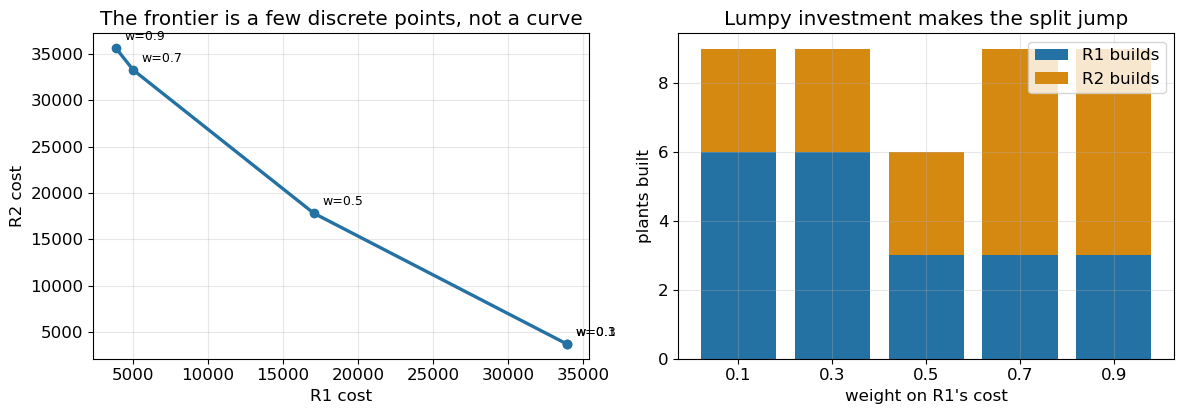

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(frontier.cost_R1, frontier.cost_R2, 'o-', lw=2.4, color='#2471a3')
for _, row in frontier.iterrows():
    ax[0].annotate(f"w={row.weight_R1:.1f}", (row.cost_R1, row.cost_R2),
                   textcoords="offset points", xytext=(6, 6), fontsize=9)
ax[0].set(xlabel="R1 cost", ylabel="R2 cost",
          title="The frontier is a few discrete points, not a curve")
ax[1].bar([str(w) for w in frontier.weight_R1], frontier.builds_R1,
          label='R1 builds', color='#2471a3')
ax[1].bar([str(w) for w in frontier.weight_R1], frontier.builds_R2,
          bottom=frontier.builds_R1, label='R2 builds', color='#d68910')
ax[1].set(xlabel="weight on R1's cost", ylabel="plants built",
          title="Lumpy investment makes the split jump")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The frontier is sharply **non-convex and nearly bang-bang**: the planner loads
essentially all capacity onto whichever region it weights *less*, because that
region's cost is discounted in the objective. Across the sweep the build split
goes 6/3 → 6/3 → 3/3 → 3/6 → 3/6 — three distinct allocations for five weights,
which is what the assertion above checks.

That shape is a direct consequence of lumpy investment: you cannot build 0.4 of a
facility, so the frontier is a set of discrete points rather than a smooth curve.
It is also why a **weighted-sum scalarisation is a weak tool** for this problem —
whole regions of the frontier are unreachable by any weight. An
$\varepsilon$-constraint formulation (minimise R1's cost subject to R2's cost
$\le$ budget) would trace it more faithfully and is worth trying.

Note the shortfall column rising at the extremes, 0.00 at $w \le 0.5$ but 0.21
at 0.7 and 1.46 at 0.9: when the planner nearly ignores one region it starts
letting demand go unserved rather than building there. Hold on to that — it is
the same mechanism that makes section 11's naive comparison impossible.

## 9. Model 4b — two firms at a fixed price

Now each region is a **profit-maximising firm**:

$$\max_{\text{firm } r} \;\;
\underbrace{\sum_p \omega_p\,\bar{p}\sum_{rt}\text{sale}_{r,rt,p}}_{\text{revenue}}
\;-\;\underbrace{\text{Cost}_r}_{\text{capex + opex + transport + disposal}}$$

The chain is unchanged — that is why section 7 wrapped it. **One constraint is
new, and it carries the entire strategic content of Part 4b:**

$$\text{sale}_{r,rt,p} \;\le\; \max\{0,\; D_{rt,p} - \overline{\text{sale}}_{-r,rt,p}\}$$

At a **fixed** price nobody buys more than the market wants, so a firm's sales
are capped by **residual demand** — whatever the rival left unserved. That single
line makes the structure a **race for market share**: at any price above marginal
cost both firms want the whole market, and whoever commits capacity first
captures it.

Watch what it costs in model size. The rivalry is 26 constraints.

In [28]:
FIRM = 'R1'
rival_sales = {(rt, p): 0.0 for rt in REGIONS for p in P}

mb = gp.Model("best_response")
mb.Params.OutputFlag = 0
mb.Params.MIPGap = MIPGAP_PLAN
h = chain(mb, FIRM, 'both', TIERS, rev_price=PRICE_FIXED)
mb.update()
before = mb.NumConstrs

# THE constraint: nobody sells more than the demand the rival left behind
mb.addConstrs((h['sale'][rt, p] <= max(0.0, DEMAND[rt, p] - rival_sales.get((rt, p), 0.0))
               for rt in REGIONS for p in P), name='residual')
mb.update()

print(f"constraints before the residual cap: {before}")
print(f"                after              : {mb.NumConstrs}"
      f"   (+{mb.NumConstrs - before} = {len(REGIONS)} markets x {len(P)} periods)")
print(f"\nthe rival sells nothing, so the cap is just demand itself:")
print(f"{'p':>3s} {'year':>5s} " + " ".join(f"{r:>9s}" for r in REGIONS))
for p in [0, 6, len(P) - 1]:
    print(f"{p:3d} {START[p]:5d} " + " ".join(f"{DEMAND[r, p]:9.2f}" for r in REGIONS))

constraints before the residual cap: 671
                after              : 697   (+26 = 2 markets x 13 periods)

the rival sells nothing, so the cap is just demand itself:
  p  year        R1        R2
  0     1    100.00     75.00
  6     7    105.74     89.78
 12    29    129.07    170.90


### 9.1 The objective, and the first solve

Revenue is `PRICE_FIXED` per unit, discounted by `OMEGA[p]` — that is the
`revenue` handle `chain()` already returns, which is why it took a `rev_price`
argument at all. Profit is revenue minus the same cost expression the planner
minimised.

> **Predict before you run.** R1 faces no rival, so the residual cap is the whole
> market. Demand over the horizon totals about 2,743 rate-units. Will R1 serve
> all of it? Its revenue is a flat 12.0 per unit and its cheapest chain costs
> rather less than that — but every plant is lumpy.

In [29]:
mb.setObjective(h['revenue'] - h['cost'], GRB.MAXIMIZE)
mb.update()
assert mb.NumVars > 0 and mb.NumConstrs > 0, "empty model"

mb.optimize()
assert mb.SolCount > 0, f"no solution; status {mb.Status}"

hand_built = mb.ObjVal
print(f"status {mb.Status}, profit {hand_built:,.4f}, gap {mb.MIPGap:.2e}")
print(f"  revenue  {h['revenue'].getValue():12,.2f}")
print(f"  cost     {h['cost'].getValue():12,.2f}")
print(f"  sales    {sum(h['sale'][rt, p].X for rt in REGIONS for p in P):12,.2f}"
      f"   of {sum(DEMAND.values()):,.1f} demanded")
print(f"  builds   {sum(1 for k in h['b'] if h['b'][k].X > 0.5):12d}")

status 2, profit 7,612.7009, gap 7.39e-04
  revenue     26,130.52
  cost        18,517.82
  sales        1,652.03   of 2,742.8 demanded
  builds              3


**R1 declines to serve the whole market even with no competition.** It sells
about 1,652 of the 2,743 rate-units demanded. At a flat price of 12.0 the revenue
on a marginal unit cannot justify committing another lumpy facility, so the
last tranche of demand simply goes unmet.

That is not a bug and it is not a solver artefact — it is what a fixed price
does. Remember it: section 11 is where it turns a straightforward comparison into
an impossible one, and Part 4c is where an endogenous price removes it.

## 10. The best response, wrapped — and the three ways this game can end

You have written the residual cap and the profit objective once. The loop below
needs them **about forty times**. Two cells: the best response, and the iteration
that calls it.

**The termination test is the interesting part, and it differs from Part 4c's.**
Here the strategy that matters is the set of plants built — a tuple of
`(stage, vintage)` pairs, which is **discrete**. So exact state matching is
correct, and a tolerance would be wrong. In Part 4c the strategy is a continuous
quantity schedule and exact matching invents cycles out of MIP-gap noise. Same
loop, opposite right answer, and the reason is the type of the strategy.

Three exits:

1. **CONVERGED** — the profile repeats immediately. A fixed point: a
   pure-strategy Nash equilibrium of the discretised game.
2. **CYCLE** — it repeats after $k \ge 2$ rounds. **No pure-strategy equilibrium
   was found**, and the cycle itself is the result: each firm builds only if the
   other does not. That is real economics, and suppressing it would be the actual
   error.
3. **MAX_ITER** — report non-convergence honestly.

In [30]:
def best_response(r, rival, learning, tiers, mipgap):
    """Section 9: the chain, the residual cap, and a profit objective."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    h_ = chain(m, r, learning, tiers, rev_price=PRICE_FIXED)
    m.addConstrs((h_['sale'][rt, p] <= max(0.0, DEMAND[rt, p] - rival.get((rt, p), 0.0))
                  for rt in REGIONS for p in P), name='residual')
    m.setObjective(h_['revenue'] - h_['cost'], GRB.MAXIMIZE)
    m.optimize()
    m._h = h_
    return m


def iterate(learning, tiers, first, max_iter, mipgap):
    """Iterated best response, terminating on the BUILD PLAN - see above."""
    sales = {r: {(rt, p): 0.0 for rt in REGIONS for p in P} for r in REGIONS}
    plans, hist, log = {}, [], []
    order = [first] + [r for r in REGIONS if r != first]
    for it in range(max_iter):
        for r in order:
            rival = {}
            for other in REGIONS:
                if other == r:
                    continue
                for k, v in sales[other].items():
                    rival[k] = rival.get(k, 0.0) + v
            b = best_response(r, rival, learning, tiers, mipgap)
            if b.SolCount == 0:
                return dict(status='INFEASIBLE', iters=it, log=log)
            sales[r] = {(rt, p): b._h['sale'][rt, p].X for rt in REGIONS for p in P}
            plans[r] = tuple(sorted((s, v) for (s, v) in b._h['b']
                                    if b._h['b'][s, v].X > 0.5))
            log.append(dict(iter=it, firm=r, profit=b.ObjVal, builds=len(plans[r]),
                            total_sales=sum(sales[r].values())))
        state = tuple(plans.get(r) for r in REGIONS)
        if state in hist:
            # repeating IMMEDIATELY is a fixed point; after k rounds it is a
            # genuine k-cycle with no pure-strategy equilibrium found
            clen = len(hist) - hist.index(state)
            return dict(status=('CONVERGED' if clen == 1 else 'CYCLE'),
                        cycle_len=clen, iters=it + 1, log=log, plans=plans,
                        sales=sales)
        hist.append(state)
    return dict(status='MAX_ITER', iters=max_iter, log=log, plans=plans, sales=sales)


print("best_response() and iterate() defined")

best_response() and iterate() defined


### 10.1 Does the wrapper reproduce the hand-built best response?

In [31]:
check = best_response(FIRM, rival_sales, 'both', TIERS, MIPGAP_PLAN)
rel = abs(check.ObjVal - hand_built) / abs(hand_built)
print(f"hand-built (section 9.1): {hand_built:,.9f}")
print(f"wrapper    (section 10) : {check.ObjVal:,.9f}")
assert rel < 1e-9, f"the wrapper is not the model you read; relative gap {rel:.2e}"
print(f"\nagree to {rel:.1e} - the wrap is earned")

hand-built (section 9.1): 7,612.700866299
wrapper    (section 10) : 7,612.700866299

agree to 0.0e+00 - the wrap is earned


## 11. Does moving first pay?

> **Predict before you run.** The firm that moves first optimises against an
> empty market and can commit capacity to whatever it likes; the second optimises
> against the leftovers. Write down whether you expect that to be worth a few
> per cent, or a lot — and whether you expect the two orders to reach the *same*
> equilibrium.

In [32]:
MAX_ITER = 10

runs, rows = {}, []
for first in REGIONS:
    res = iterate('both', TIERS, first=first, max_iter=MAX_ITER, mipgap=MIPGAP_PLAN)
    runs[first] = res
    last = {g['firm']: g for g in res['log'][-len(REGIONS):]}
    rows.append(dict(first_mover=first, status=res['status'],
                     repeat_length=res.get('cycle_len'), iterations=res['iters'],
                     **{f'profit_{r}': round(last[r]['profit'], 1) for r in REGIONS},
                     **{f'sales_{r}': round(last[r]['total_sales'], 1) for r in REGIONS}))
orders = pd.DataFrame(rows)

assert (orders.status == 'CONVERGED').all(), "a move order failed to converge"
for r in REGIONS:
    own, other = orders[f'profit_{r}'][REGIONS.index(r)], orders[f'profit_{r}'][1 - REGIONS.index(r)]
    print(f"{r}: moving first is worth {100 * (own / other - 1):5.1f}% "
          f"({own:,.1f} against {other:,.1f})")
assert orders.profit_R1[0] != orders.profit_R1[1], \
    "both move orders gave the same equilibrium; there is no first-mover effect"
orders

R1: moving first is worth  29.1% (7,612.7 against 5,895.7)
R2: moving first is worth  49.2% (3,721.6 against 2,494.5)


,first_mover,status,repeat_length,iterations,profit_R1,profit_R2,sales_R1,sales_R2
0,R1,CONVERGED,1,2,7612.7,2494.5,1652.0,987.1
1,R2,CONVERGED,1,2,5895.7,3721.6,1359.8,1303.9


Both orders reach a **fixed point** (repeat length 1), so a pure-strategy
equilibrium exists in this instance — but they reach **different** ones.

**Moving first is worth 29.1% of profit to R1 and 49.2% to R2.** That is
first-mover advantage emerging endogenously from capacity commitment: the leader
builds and locks in residual demand, and the follower optimises against what is
left. R2 gains more in percentage terms precisely because it is the weaker firm —
it has more to lose from being second.

Two consequences worth stating plainly.

**The equilibrium is not unique, so "the" answer to this game does not exist.**
Reporting one ordering would be reporting an artefact of the solution procedure.
Sweep the order — and if you extend this, sweep the starting profile too. The
assertion above fails if the two orders ever coincide, which would mean this
whole section had nothing to show.

**No cycling appeared here, but do not generalise from that.** A fixed price
makes each firm's problem well behaved. Once price responds to total quantity
(Part 4c), a firm's optimal capacity depends on the rival's output *through the
price*, and cycling becomes much more likely — Part 4c-exact finds exactly that
once the revenue approximation is removed.

In [33]:
trace = pd.DataFrame(runs['R1']['log'])
print("the mechanism, round by round, with R1 moving first:")
trace

the mechanism, round by round, with R1 moving first:


,iter,firm,profit,builds,total_sales
0,0,R1,7612.700866,3,1652.027376
1,0,R2,2494.483987,3,987.144606
2,1,R1,7612.700866,3,1652.027376
3,1,R2,2494.483987,3,987.144606


The trace shows it directly: R1 moves first against an empty market and takes
1,652.0 units; R2 then optimises against the residual and takes 987.1. From
iteration 1 onward neither firm changes anything — a fixed point, and the reason
the loop stops after 2 rounds rather than the 10 it was allowed.

## 12. The cost of rivalry — and a bound that looks violated

Comparing 4a to 4b directly is invalid: 4a minimises **cost**, 4b maximises
**profit**. The clean approach is to take the competitive *decisions* and
re-price them through the cooperative cost accounting.

But there is a trap here, and it is worth walking into deliberately, because the
naive version produces a result that is **provably impossible**.

The planner has strictly more freedom than the firms: it can choose *any* pair of
plans, including exactly the competitive one. So the planner's cost must be a
**lower bound** on the competitive cost. If a comparison says otherwise, the
comparison is wrong — not the theory.

In [34]:
res = runs['R1']
comp_cost, comp_sales = 0.0, {}
for r in REGIONS:
    rival = {}
    for other in REGIONS:
        if other == r:
            continue
        for k, v in res['sales'][other].items():
            rival[k] = rival.get(k, 0.0) + v
    br = best_response(r, rival, 'both', TIERS, MIPGAP_PLAN)
    comp_cost += br._h['cost'].getValue()
    for rt in REGIONS:
        for p in P:
            comp_sales[r, rt, p] = br._h['sale'][rt, p].X
served = {(rt, p): sum(comp_sales[r, rt, p] for r in REGIONS)
          for rt in REGIONS for p in P}

coop = planner(0.5, learning='both', tiers=TIERS, mipgap=MIPGAP_PLAN)
coop_cost = sum(coop._H[r]['cost'].getValue() for r in REGIONS)

print("--- the NAIVE comparison ---")
print(f"  cooperative planner cost   {coop_cost:10.1f}")
print(f"  competitive cost           {comp_cost:10.1f}")
print(f"  apparent cost of rivalry   {comp_cost - coop_cost:10.1f}"
      f"  ({100 * (comp_cost - coop_cost) / coop_cost:+.1f}%)")
print(f"\n  demand over horizon        {sum(DEMAND.values()):10.1f}")
print(f"  served by the firms        {sum(served.values()):10.1f}")
print(f"  UNSERVED                   {sum(DEMAND.values()) - sum(served.values()):10.1f}")

assert comp_cost < coop_cost, \
    "the naive comparison did not produce the impossible result this section is about"

--- the NAIVE comparison ---
  cooperative planner cost      34853.7
  competitive cost              31773.9
  apparent cost of rivalry      -3079.8  (-8.8%)

  demand over horizon            2742.8
  served by the firms            2639.2
  UNSERVED                        103.7


The apparent cost of rivalry is **negative** — competition looks *cheaper* than
the planner, by 8.8%. That cannot be an efficiency gain, and the assertion above
deliberately requires it, because the impossible answer is the lesson.

**The resolution is in the last line.** The planner is required to serve all
demand (or pay a shortfall penalty); the firms are not, and they simply decline
to serve about 104 rate-units — exactly the under-provision section 9.1 flagged.
So the competitive outcome **is not in the planner's feasible set**, and the two
numbers are not comparable. Serving that last tranche needs another lumpy
facility, and the planner pays for it while the firms walk away.

Two ways to repair the comparison. They answer different questions, and both
restore the bound.

In [35]:
# TEST 1 -- volume-matched: hold the planner to exactly what the firms served
mv = gp.Model()
mv.Params.OutputFlag = 0
mv.Params.MIPGap = 1e-6
Hv = {r: chain(mv, r, 'both', TIERS, rev_price=None) for r in REGIONS}
mv.addConstrs((gp.quicksum(Hv[r]['sale'][rt, p] for r in REGIONS) >= served[rt, p]
               for rt in REGIONS for p in P), name='match_volume')
mv.setObjective(gp.quicksum(Hv[r]['cost'] for r in REGIONS), GRB.MINIMIZE)
mv.optimize()
assert mv.SolCount > 0, "the volume-matched planner found no solution"

# TEST 2 -- welfare-inclusive: charge the firms the same social cost of unserved demand
pen_comp = sum(OMEGA[p] * PEN_SHORT * max(0.0, DEMAND[rt, p] - served[rt, p])
               for rt in REGIONS for p in P)
coop_total = coop_cost + coop._pen.getValue()

print("TEST 1 -- volume-matched (efficiency only)")
print(f"  planner at competitive volume {mv.ObjVal:10.1f}")
print(f"  competitive                   {comp_cost:10.1f}")
print(f"  cost of rivalry               {comp_cost - mv.ObjVal:10.1f}"
      f"  ({100 * (comp_cost - mv.ObjVal) / mv.ObjVal:+.2f}%)")
print("\nTEST 2 -- welfare-inclusive (efficiency + unserved demand)")
print(f"  planner cost + penalty        {coop_total:10.1f}")
print(f"  competitive cost + penalty    {comp_cost + pen_comp:10.1f}")
print(f"  cost of rivalry               {comp_cost + pen_comp - coop_total:10.1f}"
      f"  ({100 * (comp_cost + pen_comp - coop_total) / coop_total:+.1f}%)")

# both repairs must restore the bound; that is the point of the section
assert mv.ObjVal <= comp_cost + 1e-3, "volume-matched bound still violated"
assert coop_total <= comp_cost + pen_comp + 1e-3, "welfare-inclusive bound still violated"
print("\nboth bounds hold")

TEST 1 -- volume-matched (efficiency only)
  planner at competitive volume    31471.4
  competitive                      31773.9
  cost of rivalry                    302.6  (+0.96%)

TEST 2 -- welfare-inclusive (efficiency + unserved demand)
  planner cost + penalty           34864.1
  competitive cost + penalty       46810.4
  cost of rivalry                  11946.3  (+34.3%)

both bounds hold


Both repairs restore the bound, and the two numbers answer different questions:

| Comparison | Cost of rivalry | What it measures |
|---|---|---|
| Naive (different volumes) | **−8.8%** | nothing — invalid |
| Volume-matched | **+0.96%** | pure productive inefficiency of splitting output between two firms |
| Welfare-inclusive | **+34.3%** | that inefficiency **plus** the social loss from 103.7 units never produced |

The volume-matched figure is small, which is itself informative: given *what*
gets produced, two firms produce it almost as cheaply as a planner would. Nearly
all of the welfare cost of rivalry in this model is the **under-provision** —
capacity that no firm finds privately worth building.

That under-provision is an artefact of the **fixed price**, though. At a constant
price the revenue on a marginal unit cannot rise to justify a lumpy facility.
With an endogenous price (Part 4c) unserved demand raises the price and draws
capacity in, so the quantity distortion largely disappears and the remaining gap
becomes interpretable as genuine strategic inefficiency.

**The general lesson**: when a comparison violates a bound you can prove, the
error is in the comparison. Check first whether the two models are solving the
same problem — most often they differ in a *constraint* (here, the obligation to
serve demand) rather than in anything economic.

## 13. Learning under rivalry

Part 3b found production learning did not change the plan under cost
minimisation, because cumulative production was pinned by demand. In a game
quantity is a **decision**, so the channel finally has a lever.

> **Predict before you run.** Turning the production channel off means every unit
> is operated at full price — no tier discount ever. Do you expect that to change
> profits by a few per cent, or to change what gets *built*?

In [36]:
rows = []
for lm in ['capacity', 'both']:
    r2 = iterate(lm, TIERS, first='R1', max_iter=MAX_ITER, mipgap=MIPGAP_PLAN)
    last = {g['firm']: g for g in r2['log'][-len(REGIONS):]}
    rows.append(dict(learning=lm, status=r2['status'],
                     **{f'profit_{r}': round(last[r]['profit'], 1) for r in REGIONS},
                     **{f'sales_{r}': round(last[r]['total_sales'], 1) for r in REGIONS},
                     **{f'builds_{r}': last[r]['builds'] for r in REGIONS}))
learning_table = pd.DataFrame(rows)

flat, tiered = learning_table.iloc[0], learning_table.iloc[1]
print(f"without the production channel: {flat.builds_R1 + flat.builds_R2} plants built "
      f"in total, sales {flat.sales_R1 + flat.sales_R2:,.1f}")
print(f"with it                       : {tiered.builds_R1 + tiered.builds_R2} plants built "
      f"in total, sales {tiered.sales_R1 + tiered.sales_R2:,.1f}")
for r in REGIONS:
    print(f"  {r}: sales {flat[f'sales_{r}']:7.1f} -> {tiered[f'sales_{r}']:7.1f}"
          f"  ({100 * (tiered[f'sales_{r}'] / flat[f'sales_{r}'] - 1):5.1f}% more)"
          f"   profit {flat[f'profit_{r}']:8.1f} -> {tiered[f'profit_{r}']:8.1f}")
assert flat.builds_R1 + flat.builds_R2 < tiered.builds_R1 + tiered.builds_R2, \
    "the production channel did not change what gets built"
learning_table

without the production channel: 0 plants built in total, sales 1,403.5
with it                       : 6 plants built in total, sales 2,639.1
  R1: sales   933.3 ->  1652.0  ( 77.0% more)   profit   2486.9 ->   7612.7
  R2: sales   470.2 ->   987.1  (109.9% more)   profit    815.0 ->   2494.5


,learning,status,profit_R1,profit_R2,sales_R1,sales_R2,builds_R1,builds_R2
0,capacity,CONVERGED,2486.9,815.0,933.3,470.2,0,0
1,both,CONVERGED,7612.7,2494.5,1652.0,987.1,3,3


**The production channel does not merely reduce cost here — it decides whether
anything gets built at all.**

Without it, neither firm builds a single plant: R1 earns 2,486.9 and R2 815.0,
selling 933.3 and 470.2 out of legacy capacity alone. With it, both build three
plants, sales rise to 1,652.0 and 987.1 — up 77.0% and 109.9% — and profits
roughly triple, to 7,612.7 and 2,494.5.

The mechanism is the tier discount. Operating every unit at full price makes the
chain expensive enough that a lumpy facility never pays for itself at a fixed
price of 12.0. The tiers cut operating cost by 18% and then 33%, and that is what
tips the investment decision.

**So keep the channel in the formulation**, and note that the reason is stronger
than "it is a cost reduction". The asymmetry in `EXPERIENCE0` is also doing what
it was built to do: R1 starts several tiers up the curve and holds a durable
operating-cost advantage that R2's cheaper capital cannot fully offset. That
advantage is what Part 4c turns into a reason to *flood the market*.

One caveat on reading this table. `learning='capacity'` removes the tier block
entirely rather than setting the tiers to 1.0, so the comparison is "tiered opex
versus flat opex", not "learning versus no learning at the same cost level". The
two firms are genuinely more expensive to run in the first row, which is the
point, but it is not a pure information effect.

## 14. The agreement assertion

Everything above was built by hand, and `src/lithium/` holds the same models as
functions. **The same model exists twice, deliberately** — and deliberate
duplication with nothing comparing the copies is how a bug gets fixed in three
places out of four.

This cell imports the package, hands it the same instance dictionaries and the
same knobs, runs the same case as section 9.1, and asserts the two objectives
agree to $10^{-9}$.

In [37]:
from lithium import Instance, best_response_fixed_price, build_structure

nb_instance = Instance(
    regions=tuple(REGIONS), stages=tuple(STAGES),
    fixed=FIXED, unit=UNIT, opex=OPEX,
    legacy_cap=LEGACY_CAP, legacy_ret=LEGACY_RET,
    eta_ceil=ETA_CEIL, eta_base=ETA_BASE, alpha=ALPHA, beta=BETA, delta_bar=DELTA_BAR,
    demand_base=DEMAND_BASE, demand_growth=DEMAND_GROWTH, experience0=EXPERIENCE0,
)
nb_struct = build_structure(nb_instance, blocks=BLOCKS, dr=DR, life=LIFE, lead=LEAD,
                            cap_min=CAP_MIN, cap_max=CAP_MAX,
                            legacy_byr=LEGACY_BYR, eta_floor=ETA_FLOOR)

packaged = best_response_fixed_price(
    FIRM, rival_sales, nb_struct,
    learning='both', mipgap=MIPGAP_PLAN,
    transport=TRANSPORT, pen_dispose=PEN_DISPOSE, price_fixed=PRICE_FIXED,
    capex_curve=(QBP, CBP), learn_stages=LEARN_STAGES,
    tiers=TIERS, n_tiers=N_TIERS, lag_years=LAG_YEARS,
)

rel = abs(packaged.ObjVal - hand_built) / abs(hand_built)
print(f"notebook (section 9.1, by hand): {hand_built:,.9f}")
print(f"package  (lithium.games)       : {packaged.ObjVal:,.9f}")
assert rel < 1e-9, f"notebook and package disagree by {rel:.2e}"
print(f"\nnotebook and package agree to {rel:.1e}")

notebook (section 9.1, by hand): 7,612.700866299
package  (lithium.games)       : 7,612.700866299

notebook and package agree to 0.0e+00


## 15. Summary

| Question | Answer |
|---|---|
| Is Part 4a a game? | **No.** One objective function, one decision maker. It is a cooperative bound |
| What shape is the Pareto frontier? | Three discrete allocations for five weights — lumpy investment makes it jump |
| Does moving first pay at a fixed price? | **Yes** — 29.1% to R1, 49.2% to R2, and the two orders reach different equilibria |
| Is the equilibrium unique? | **No.** Reporting one move order would be reporting an artefact |
| What is the cost of rivalry? | **+0.96%** volume-matched, **+34.3%** welfare-inclusive. The naive answer, −8.8%, is impossible |
| Does production learning matter in a game? | **Decisively** — without it neither firm builds anything at all |

### Formulation lessons

- **One constraint can be the whole model.** Part 4b's residual demand cap is 26
  constraints and it carries all of the strategic content.
- **The termination test follows from the type of the strategy.** Discrete build
  plans take exact matching; Part 4c's continuous quantities need a tolerance.
  Using the wrong one either invents cycles or misses them.
- **A cycle is a result, not a bug.** If no pure-strategy equilibrium exists,
  reporting one would be the error.
- **When a comparison violates a bound you can prove, fix the comparison.** Check
  whether the two models are solving the same problem — usually they differ in a
  constraint, not in economics.
- **A weighted-sum scalarisation is a weak tool on a lumpy frontier.** Whole
  regions of it are unreachable by any weight.

### Things to try

- `PRICE_FIXED = 16.0` — a higher price should draw in the capacity that
  under-provision left out, and shrink the welfare-inclusive cost of rivalry
- `WEIGHTS = [0.4, 0.45, 0.5, 0.55, 0.6]` — zoom in on the frontier's flip and
  see whether anything lives between the discrete allocations
- `MAX_ITER = 2` — force a MAX_ITER exit and check the code reports it honestly
  rather than pretending to converge
- In section 2.2, `EXPERIENCE0['R1'] = 500.0` — remove incumbency, and watch
  section 13's asymmetry disappear

### Where this goes next

**Part 4c — Cournot.** Price responds to quantity, so the residual cap disappears
and the rivalry runs through the price itself. That single change removes the
under-provision this notebook measured, and largely dissolves the first-mover
advantage it just found — from 29.1% to 4.4%.